Ad =
 [[ 0.99984535  0.09953212  0.00452419]
 [-0.00452419  0.98627279  0.08595955]
 [-0.08595955 -0.26240285  0.72839412]]
Cd =
 [[1. 0. 0.]]

Observer gain L =
 [[ 2.11451225]
 [12.15090928]
 [15.49144942]]
Observer error dynamics eig(Ad - LCd) = [0.1 0.2 0.3]
Magnitudes |eig| = [0.1 0.2 0.3]


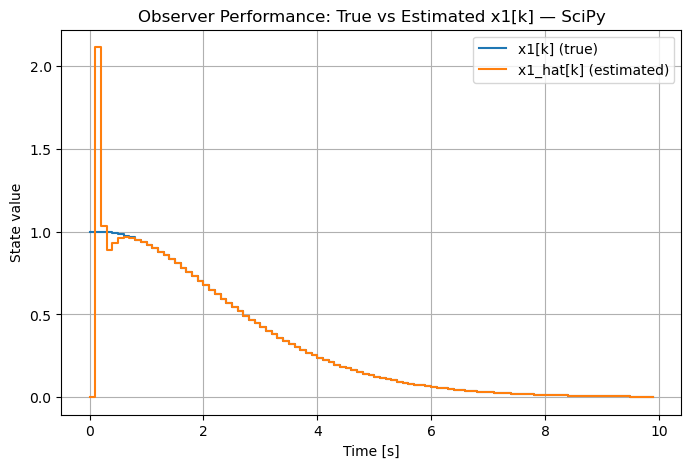

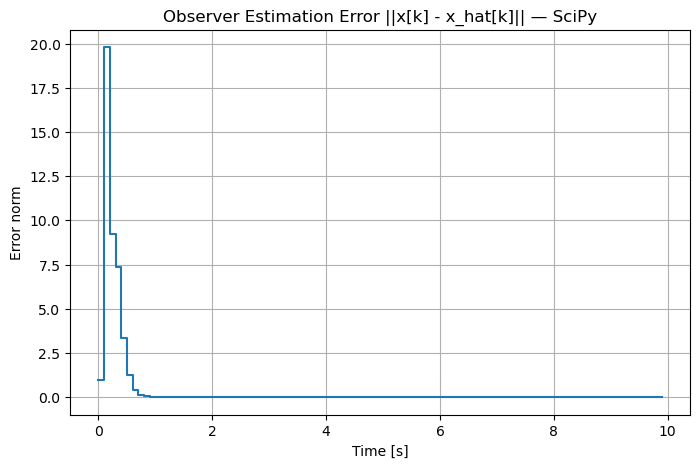

In [6]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# -----------------------------------------
# STEP 1 — Continuous model (same as ACS Task 2)
# -----------------------------------------

A = np.array([[0, 1, 0],
              [0, 0, 1],
              [-1, -3, -3]], dtype=float)

B = np.array([[0],
              [0],
              [1]], dtype=float)

C = np.array([[1, 0, 0]], dtype=float)
D = np.array([[0]], dtype=float)

Ts = 0.1

# -----------------------------------------
# STEP 2 — Discretize system using ZOH
# -----------------------------------------

Ad, Bd, Cd, Dd, dt = signal.cont2discrete((A, B, C, D), Ts, method='zoh')

print("Ad =\n", Ad)
print("Cd =\n", Cd)

# -----------------------------------------
# STEP 3 — Observer gain L via pole placement
# Want eig(Ad - L*Cd) = [0.1, 0.2, 0.3]
# -----------------------------------------

p_obs = np.array([0.1, 0.2, 0.3])

# Duality: place poles for (Ad - L Cd) by placing poles of (Ad^T - Cd^T K)
place_L = signal.place_poles(Ad.T, Cd.T, p_obs)
L = place_L.gain_matrix.T   # (3x1)

print("\nObserver gain L =\n", L)

eig_obs = np.linalg.eigvals(Ad - L @ Cd)
print("Observer error dynamics eig(Ad - LCd) =", eig_obs)
print("Magnitudes |eig| =", np.abs(eig_obs))

# -----------------------------------------
# STEP 4 — Simulate true system and observer (zero input)
# x[k+1]     = Ad x[k]
# xhat[k+1]  = Ad xhat[k] + L (y[k] - Cd xhat[k])
# -----------------------------------------

steps = 100

x = np.zeros((3, steps))
xhat = np.zeros((3, steps))

# initial conditions (same style as your python-control)
x[:, 0] = np.array([1.0, 0.0, 0.0])     # true initial state
xhat[:, 0] = np.array([0.0, 0.0, 0.0])  # estimator initial guess

u = 0.0  # zero input

for k in range(steps - 1):
    # true plant
    x[:, k+1] = (Ad @ x[:, k]) + (Bd.flatten() * u)
    yk = (Cd @ x[:, k]).item()  # scalar output

    # observer
    yhat_k = (Cd @ xhat[:, k]).item()
    ek = yk - yhat_k
    xhat[:, k+1] = (Ad @ xhat[:, k]) + (Bd.flatten() * u) + (L.flatten() * ek)

t_disc = np.arange(steps) * Ts

# -----------------------------------------
# STEP 5 — Plot: true vs estimated x1
# -----------------------------------------

plt.figure(figsize=(8,5))
plt.step(t_disc, x[0, :], where='post', label='x1[k] (true)')
plt.step(t_disc, xhat[0, :], where='post', label='x1_hat[k] (estimated)')
plt.title("Observer Performance: True vs Estimated x1[k] — SciPy")
plt.xlabel("Time [s]")
plt.ylabel("State value")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------------------
# STEP 6 — Estimation error norm
# -----------------------------------------

err = np.linalg.norm(x - xhat, axis=0)

plt.figure(figsize=(8,5))
plt.step(t_disc, err, where='post')
plt.title("Observer Estimation Error ||x[k] - x_hat[k]|| — SciPy")
plt.xlabel("Time [s]")
plt.ylabel("Error norm")
plt.grid(True)
plt.show()


Continuous-time model created.

State feedback gain K = [[23. 23.  6.]]
Closed-loop eigenvalues eig(A-BK) = [-2. -3. -4.]

Feedforward gain W = 23.999999999999655


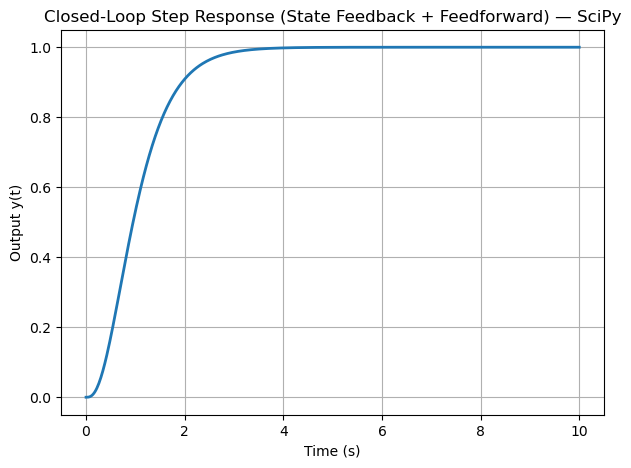


Discrete closed-loop eigenvalues eig(Ad - Bd K) = [0.81403117 0.77793133 0.4991791 ]
Magnitudes |eig| = [0.81403117 0.77793133 0.4991791 ]


In [5]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# -----------------------------------------
# STEP 1 — Define continuous-time state-space model
# -----------------------------------------

A = np.array([[0, 1, 0],
              [0, 0, 1],
              [-1, -3, -3]], dtype=float)

B = np.array([[0],
              [0],
              [1]], dtype=float)

C = np.array([[1, 0, 0]], dtype=float)
D = np.array([[0]], dtype=float)

print("Continuous-time model created.")

# -----------------------------------------
# STEP 2 — Compute state feedback gain K (pole placement)
# Desired poles: [-2, -3, -4]
# -----------------------------------------

desired_poles = np.array([-2.0, -3.0, -4.0])

# SciPy pole placement
place_obj = signal.place_poles(A, B, desired_poles)
K = place_obj.gain_matrix          # shape (1,3)

print("\nState feedback gain K =", K)

Ak = A - B @ K
eig_cl = np.linalg.eigvals(Ak)
print("Closed-loop eigenvalues eig(A-BK) =", eig_cl)

# -----------------------------------------
# STEP 3 — Compute feedforward gain W for reference tracking
# u = -Kx + W r
# W = -1 / (C (A-BK)^(-1) B)
# -----------------------------------------

scalar = (C @ np.linalg.inv(Ak) @ B).item()   # extract 1x1 -> scalar
W = -1.0 / scalar

print("\nFeedforward gain W =", W)

# -----------------------------------------
# STEP 4 — Closed-loop system (Part 2/2: build + simulate)
# x' = (A-BK)x + B*W*r
# y  = Cx
# -----------------------------------------

B_cl = B * W
sys_cl = signal.StateSpace(Ak, B_cl, C, D)

T = np.linspace(0, 10, 500)
t_step, y_step = signal.step(sys_cl, T=T)

plt.figure(figsize=(7,5))
plt.plot(t_step, y_step, linewidth=2)
plt.title("Closed-Loop Step Response (State Feedback + Feedforward) — SciPy")
plt.xlabel("Time (s)")
plt.ylabel("Output y(t)")
plt.grid(True)
plt.show()

# -----------------------------------------
# STEP 5 — (Optional) Discrete-time closed-loop equations (for report)
# x[n+1] = (Ad - Bd K) x[n] + Bd W r[n]
# -----------------------------------------

Ts = 0.1
Ad, Bd, Cd, Dd, dt = signal.cont2discrete((A, B, C, D), Ts, method='zoh')

A_d_cl = Ad - Bd @ K
B_d_cl = Bd * W

eig_d = np.linalg.eigvals(A_d_cl)
print("\nDiscrete closed-loop eigenvalues eig(Ad - Bd K) =", eig_d)
print("Magnitudes |eig| =", np.abs(eig_d))


Continuous-time model created (A, B, C, D).

Discrete-time matrices (ZOH):
Ad =
 [[ 0.99984535  0.09953212  0.00452419]
 [-0.00452419  0.98627279  0.08595955]
 [-0.08595955 -0.26240285  0.72839412]]
Bd =
 [[0.00015465]
 [0.00452419]
 [0.08595955]]
Cd =
 [[1. 0. 0.]]
Dd =
 [[0.]]
Ts = 0.1

Eigenvalues of Ad: [0.90483921+0.00000000e+00j 0.90483652+1.55292972e-06j
 0.90483652-1.55292972e-06j]
Magnitudes |eig(Ad)|: [0.90483921 0.90483652 0.90483652]


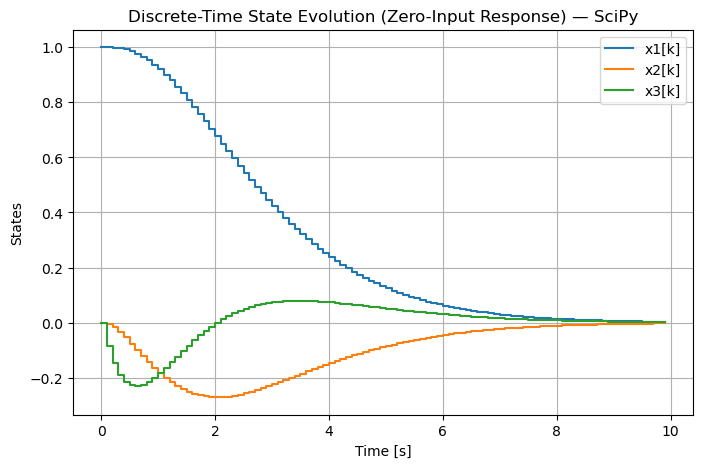

In [4]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# -----------------------------------------
# STEP 1 — Continuous-time state-space model
# (same as ACS Task 2)
# -----------------------------------------

A = np.array([[0, 1, 0],
              [0, 0, 1],
              [-1, -3, -3]], dtype=float)

B = np.array([[0],
              [0],
              [1]], dtype=float)

C = np.array([[1, 0, 0]], dtype=float)
D = np.array([[0]], dtype=float)

print("Continuous-time model created (A, B, C, D).")

# -----------------------------------------
# STEP 2 — Discretize using Zero-Order Hold (ZOH)
# sample time Ts = 0.1 s (same as report)
# -----------------------------------------

Ts = 0.1
# cont2discrete returns (Ad, Bd, Cd, Dd, dt)
Ad, Bd, Cd, Dd, dt = signal.cont2discrete((A, B, C, D), Ts, method='zoh')

print("\nDiscrete-time matrices (ZOH):")
print("Ad =\n", Ad)
print("Bd =\n", Bd)
print("Cd =\n", Cd)
print("Dd =\n", Dd)
print("Ts =", dt)

# -----------------------------------------
# STEP 3 — Eigenvalues of Ad (discrete stability)
# -----------------------------------------

eig_Ad = np.linalg.eigvals(Ad)
print("\nEigenvalues of Ad:", eig_Ad)
print("Magnitudes |eig(Ad)|:", np.abs(eig_Ad))

# -----------------------------------------
# STEP 4 — Zero-input discrete simulation
# x[k+1] = Ad x[k] + Bd u[k], with u[k] = 0
# -----------------------------------------

steps = 100
x0 = np.array([1.0, 0.0, 0.0])     # initial state [1; 0; 0]
X = np.zeros((3, steps))
X[:, 0] = x0

u = 0.0  # zero input

for k in range(steps - 1):
    X[:, k+1] = Ad @ X[:, k] + (Bd.flatten() * u)

t_disc = np.arange(steps) * Ts

# -----------------------------------------
# STEP 5 — Plot discrete state trajectories
# -----------------------------------------

plt.figure(figsize=(8,5))
plt.step(t_disc, X[0, :], where='post', label='x1[k]')
plt.step(t_disc, X[1, :], where='post', label='x2[k]')
plt.step(t_disc, X[2, :], where='post', label='x3[k]')
plt.title("Discrete-Time State Evolution (Zero-Input Response) — SciPy")
plt.xlabel("Time [s]")
plt.ylabel("States")
plt.grid(True)
plt.legend()
plt.show()


State-space model created (SciPy).


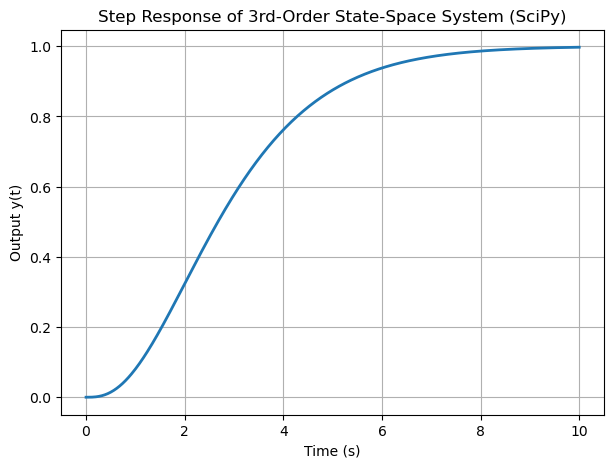

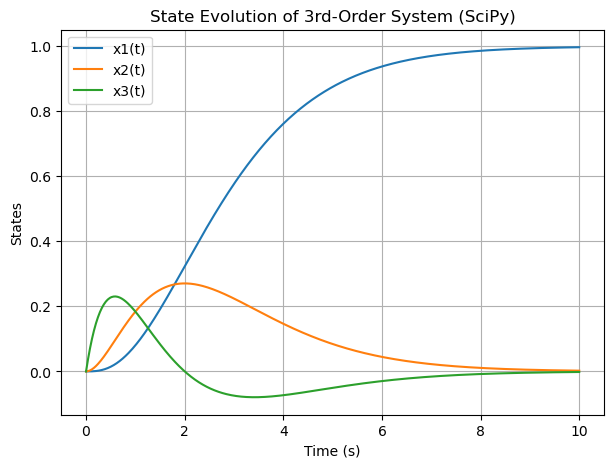

Eigenvalues of A: [-1.0000098+0.00000000e+00j -0.9999951+8.48683615e-06j
 -0.9999951-8.48683615e-06j]
Rank of controllability matrix: 3
Rank of observability matrix: 3


In [3]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# -----------------------------------------
# STEP 1 — Create the State-Space Model
# (Same A, B, C, D as in ACS Task 2)
# -----------------------------------------

A = np.array([[0, 1, 0],
              [0, 0, 1],
              [-1, -3, -3]], dtype=float)

B = np.array([[0],
              [0],
              [1]], dtype=float)

C = np.array([[1, 0, 0]], dtype=float)
D = np.array([[0]], dtype=float)

sys = signal.StateSpace(A, B, C, D)
print("State-space model created (SciPy).")

# -----------------------------------------
# STEP 2 — Step Response of the System
# -----------------------------------------

T = np.linspace(0, 10, 500)   # fixed time vector for fair comparison
t_step, y_step = signal.step(sys, T=T)

plt.figure(figsize=(7,5))
plt.plot(t_step, y_step, linewidth=2)
plt.title("Step Response of 3rd-Order State-Space System (SciPy)")
plt.xlabel("Time (s)")
plt.ylabel("Output y(t)")
plt.grid(True)
plt.show()

# -----------------------------------------
# STEP 3 — State Evolution (x1, x2, x3)
# Use lsim to extract state trajectories
# -----------------------------------------

u = np.ones_like(T)  # step input u(t)=1
t_lsim, y_lsim, x_lsim = signal.lsim(sys, U=u, T=T)

plt.figure(figsize=(7,5))
plt.plot(t_lsim, x_lsim[:, 0], label="x1(t)")
plt.plot(t_lsim, x_lsim[:, 1], label="x2(t)")
plt.plot(t_lsim, x_lsim[:, 2], label="x3(t)")
plt.title("State Evolution of 3rd-Order System (SciPy)")
plt.xlabel("Time (s)")
plt.ylabel("States")
plt.grid(True)
plt.legend()
plt.show()

# -----------------------------------------
# STEP 4 — Stability (Eigenvalues of A)
# -----------------------------------------

eigA = np.linalg.eigvals(A)
print("Eigenvalues of A:", eigA)

# -----------------------------------------
# STEP 5 — Controllability & Observability (Rank test)
# -----------------------------------------

def ctrb(A, B):
    n = A.shape[0]
    Co = B
    for i in range(1, n):
        Co = np.hstack((Co, np.linalg.matrix_power(A, i) @ B))
    return Co

def obsv(A, C):
    n = A.shape[0]
    Ob = C
    for i in range(1, n):
        Ob = np.vstack((Ob, C @ np.linalg.matrix_power(A, i)))
    return Ob

Co = ctrb(A, B)
Ob = obsv(A, C)

print("Rank of controllability matrix:", np.linalg.matrix_rank(Co))
print("Rank of observability matrix:", np.linalg.matrix_rank(Ob))



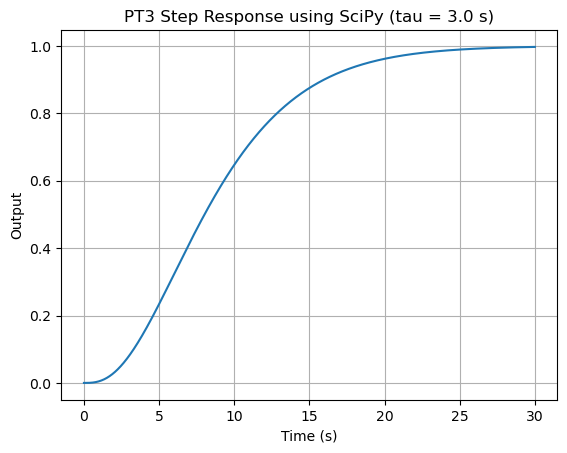

In [2]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

tau3 = 3.0

# PT1: 1/(tau s + 1)
num1 = [1]
den1 = [tau3, 1]

# PT3 = PT1^3  => multiply transfer function 3 times
num3 = np.polymul(np.polymul(num1, num1), num1)
den3 = np.polymul(np.polymul(den1, den1), den1)

sys3 = signal.TransferFunction(num3, den3)

t = np.linspace(0, 30, 1500)   # longer time for PT3
t, y3 = signal.step(sys3, T=t)

plt.plot(t, y3)
plt.title("PT3 Step Response using SciPy (tau = 3.0 s)")
plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.grid(True)
plt.show()


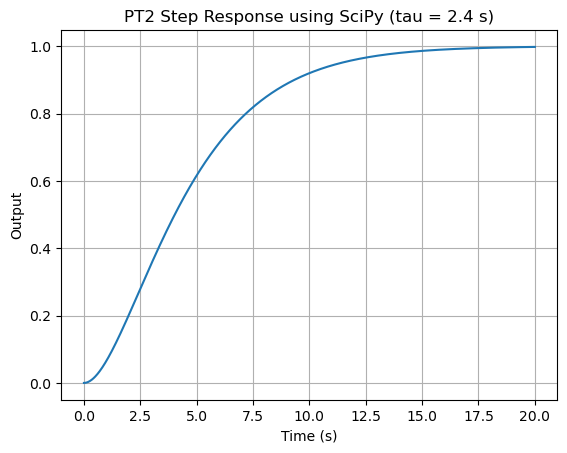

In [1]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

tau2 = 2.4

# PT1: 1/(tau s + 1)
num1 = [1]
den1 = [tau2, 1]

# PT2 = PT1^2  => multiply transfer functions
num2 = np.polymul(num1, num1)
den2 = np.polymul(den1, den1)

sys2 = signal.TransferFunction(num2, den2)

t = np.linspace(0, 20, 1000)   # longer time for PT2
t, y2 = signal.step(sys2, T=t)

plt.plot(t, y2)
plt.title("PT2 Step Response using SciPy (tau = 2.4 s)")
plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.grid(True)
plt.show()


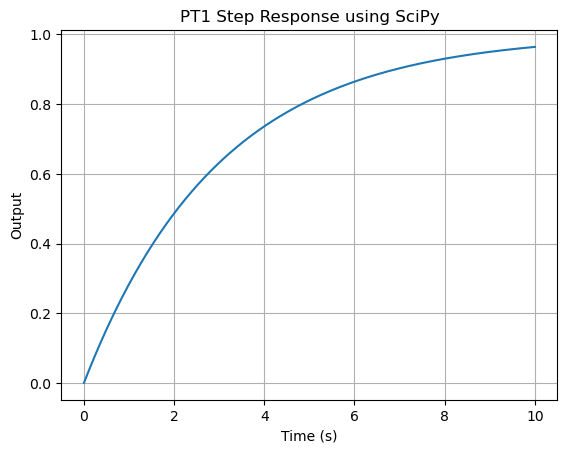

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

tau = 3.0
num = [1]
den = [tau, 1]

sys = signal.TransferFunction(num, den)

t = np.linspace(0, 10, 500)
t, y = signal.step(sys, T=t)

plt.plot(t, y)
plt.title("PT1 Step Response using SciPy")
plt.xlabel("Time (s)")
plt.ylabel("Output")
plt.grid(True)
plt.show()
